# FastML Tutorial – Jet Tagging with hls4ml

Identify jets from the LHC using a neural network  
and deploy the model to FPGA firmware using hls4ml.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nairods/Scies4Free-FastML-tutorial/blob/main/FastML.ipynb)

# 1. Import Libraries

In [28]:
import numpy as np
import tensorflow as tf
import pandas as pd

from tensorflow.keras.utils import to_categorical
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import sys
!{sys.executable} -m pip install hls4ml

%matplotlib inline
RANDOM_STATE = 42

## 2. Load Dataset

In [29]:
!rm -rf /content/Scies4Free-FastML-tutorial
!git clone https://github.com/nairods/Scies4Free-FastML-tutorial.git
DATA_PATH = "Scies4Free-FastML-tutorial/data/jet_tagging/"

train = np.load(DATA_PATH + "train.npz", allow_pickle=True)
val   = np.load(DATA_PATH + "val.npz", allow_pickle=True)
test  = np.load(DATA_PATH + "test.npz", allow_pickle=True)

feature_names = ['zlogz', 'c1_b0_mmdt', 'c1_b1_mmdt', 'c1_b2_mmdt', 'c2_b1_mmdt', 'c2_b2_mmdt', 'd2_b1_mmdt', 'd2_b2_mmdt', 'd2_a1_b1_mmdt', 'd2_a1_b2_mmdt', 'm2_b1_mmdt', 'm2_b2_mmdt', 'n2_b1_mmdt', 'n2_b2_mmdt', 'mass_mmdt', 'multiplicity']

X_train, y_train = train["X"], train["y"]
X_val,   y_val   = val["X"],   val["y"]
X_test,  y_test  = test["X"],  test["y"]

Cloning into 'Scies4Free-FastML-tutorial'...
remote: Enumerating objects: 374, done.
remote: Counting objects: 100% (138/138), done.
remote: Compressing objects: 100% (137/137), done.
remote: Total 374 (delta 79), reused 1 (delta 1), pack-reused 236 (from 1)
Receiving objects: 100% (374/374), 97.03 MiB | 17.21 MiB/s, done.
Resolving deltas: 100% (183/183), done.


We need to convert the class labels into one-hot vectors so that they match the softmax output of the network  
and can be properly compared using categorical cross-entropy loss.

One-hot encoding represents each class as a vector with a 1 at the correct class position and 0 elsewhere:
- class 0 -> (1,0,0,0,0)
- class 1 -> (0,1,0,0,0)
- class 2 -> (0,0,1,0,0)
- class 3 -> (0,0,0,1,0)
- class 4 -> (0,0,0,0,1)

In [30]:
# Convert Labels to One-Hot representation
y_train = to_categorical(y_train, 5)
y_val = to_categorical(y_val, 5)
y_test = to_categorical(y_test, 5)

## 3. Load the Neural Network

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1
import sys
repo_path = "/content/Scies4Free-FastML-tutorial"
sys.path.insert(0, repo_path)
from callbacks import all_callbacks

In [32]:
model = Sequential()
model.add(Dense(64, input_shape=(16,), name='fc1', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='relu', name='relu1'))
model.add(Dense(32, name='fc2', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='relu', name='relu2'))
model.add(Dense(32, name='fc3', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='relu', name='relu3'))
model.add(Dense(5, name='output', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='softmax', name='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
train = True
if train:
    adam = Adam(learning_rate=0.0001)
    model.compile(
        optimizer=adam,
        loss=['categorical_crossentropy'],
        metrics=['accuracy']
    )

    callbacks = all_callbacks(
        stop_patience=1000,
        lr_factor=0.5,
        lr_patience=10,
        lr_epsilon=0.000001,
        lr_cooldown=2,
        lr_minimum=0.0000001,
        outputDir='jet_models',
        model_tag='mlp'
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        batch_size=1024,
        epochs=20,
        shuffle=True,
        callbacks=callbacks.callbacks,
        verbose=1
    )
else:
    from tensorflow.keras.models import load_model
    model = load_model('jet_models/mlp_best.keras')

Epoch 1/20
566/568 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4072 - loss: 1.4698
***callbacks***
saving losses to jet_models/mlp_losses.log

Epoch 1: val_loss improved from None to 1.10914, saving model to jet_models/mlp_best.keras

Epoch 1: finished saving model to jet_models/mlp_best.keras

Epoch 1: val_loss improved from None to 1.10914, saving model to jet_models/mlp_best.weights.h5

Epoch 1: finished saving model to jet_models/mlp_best.weights.h5

Epoch 1: saving model to jet_models/mlp_last.keras

Epoch 1: finished saving model to jet_models/mlp_last.keras

Epoch 1: saving model to jet_models/mlp_last.weights.h5

Epoch 1: finished saving model to jet_models/mlp_last.weights.h5

Epoch 1: saving model to jet_models/mlp_epoch01.keras

Epoch 1: finished saving model to jet_models/mlp_epoch01.keras

***callbacks end***

568/568 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.5225 - loss: 1.3052 - val_accuracy: 0.6427 - val_loss: 1.1091 - learning_rate: 1.0000e-04
Epoch 2/20
558

# 4. Convert to FPGA Firmware with hls4ml

Next, we will convert the trained Keras model into a **low-latency FPGA implementation** using `hls4ml`.  
First, we will check that the classification performance remains accurate when using **fixed-point data types**.  
Then, we will synthesize the model with **Vitis HLS** and inspect its **latency and FPGA resource usage**.

### Create an hls4ml configuration and model

The `hls4ml` library uses a **configuration dictionary** to control how the neural network is translated to FPGA firmware.  
Here, we will show a **simple configuration**, however more advanced settings are possible.

In [34]:
import hls4ml
import plotting

config = hls4ml.utils.config_from_keras_model(model, granularity='model', backend='Vitis')
print("-----------------------------------")
print("Configuration")
plotting.print_dict(config)
print("-----------------------------------")
hls_model = hls4ml.converters.convert_from_keras_model(
    model, hls_config=config, backend='Vitis', output_dir='model_1/hls4ml_prj', part='xcu250-figd2104-2L-e'
)

-----------------------------------
Configuration
Model
  Precision
    default:         fixed<16,6>
  ReuseFactor:       1
  Strategy:          Latency
  BramFactor:        1000000000
  TraceOutput:       False
-----------------------------------


Let's visualise what we created. The model architecture is shown, annotated with the shape and data types

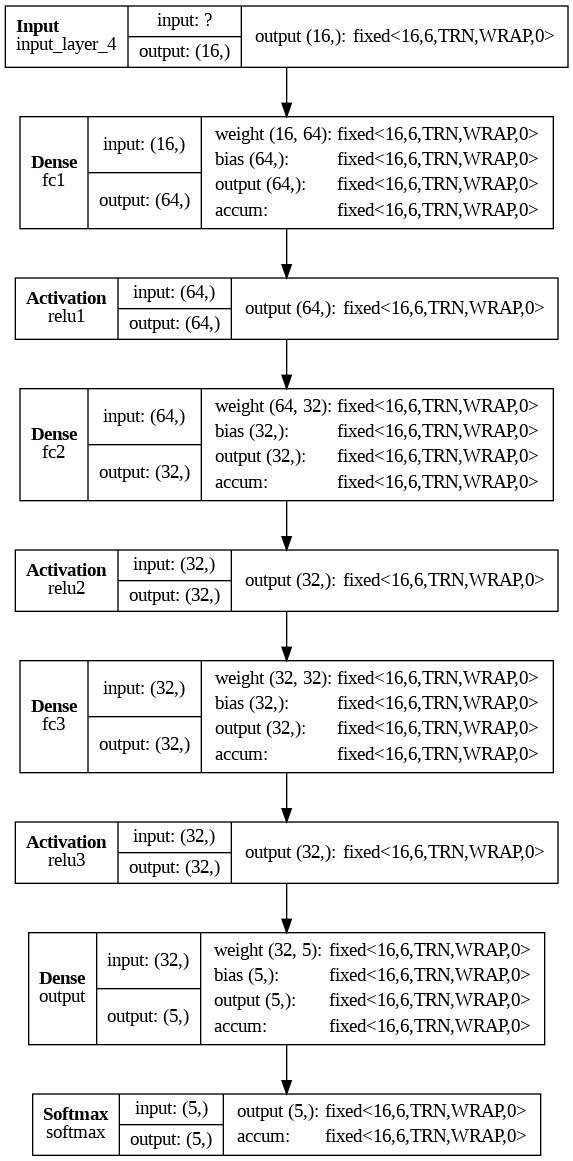

In [35]:
hls4ml.utils.plot_model(hls_model, show_shapes=True, show_precision=True, to_file=None)

## 3.1 Compile, predict
Now we need to check that this model performance is still good. We compile the hls_model, and then use `hls_model.predict` to execute the FPGA firmware with bit-accurate emulation on the CPU.

In [36]:
hls_model.compile()
X_test = np.ascontiguousarray(X_test)
y_hls = hls_model.predict(X_test)

## 3.2 Compare
That was easy! Now let's see how the performance compares to Keras:

3891/3891 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
Keras  Accuracy: 0.7459759036144579
hls4ml Accuracy: 0.7460963855421687


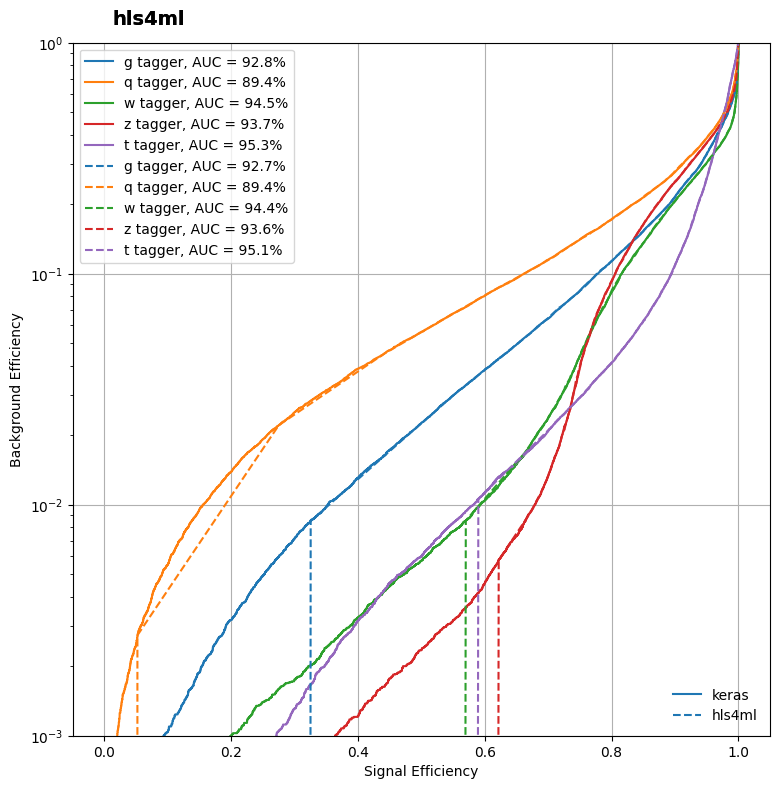

In [43]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

classes = ['g', 'q', 'w', 'z', 't']

y_score = model.predict(X_test)
print("Keras  Accuracy: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_score, axis=1))))
print("hls4ml Accuracy: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_hls, axis=1))))

fig, ax = plt.subplots(figsize=(9, 9))
_ = plotting.makeRoc(y_test, y_score, classes)
plt.gca().set_prop_cycle(None)  # reset the colors
_ = plotting.makeRoc(y_test, y_hls, classes, linestyle='--')

from matplotlib.lines import Line2D

lines = [Line2D([0], [0], ls='-'), Line2D([0], [0], ls='--')]
from matplotlib.legend import Legend

leg = Legend(ax, lines, labels=['keras', 'hls4ml'], loc='lower right', frameon=False)
ax.add_artist(leg)

# 4. Synthesize
Now we will use **Vitis HLS** to synthesize the model into FPGA firmware.  
We can start the build directly from our `hls_model` object.  

After synthesis, the generated IP can be integrated into a workflow to compile for a specific FPGA board.  
For this tutorial, we will focus on **reviewing the reports** generated by Vitis HLS, paying attention to **latency** and **resource usage**.

**Note:** This step can take several minutes.

In [ ]:
hls_model.build(csim=False)

## 4.1 Check the reports
Print out the reports generated by Vitis HLS. Pay attention to the Latency and the 'Utilization Estimates' sections

In [ ]:
hls4ml.report.read_vivado_report('model_1/hls4ml_prj/')